<a href="https://colab.research.google.com/github/Rvpatil-tech/Machine-learning-projects-/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 :: IMPORT

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/data/real_estate_price_size_year_view.csv')

In [ ]:
data.head()

,price,size,year,view
0,234314.144,643.09,2015,No sea view
1,228581.528,656.22,2009,No sea view
2,281626.336,487.29,2018,Sea view
3,401255.608,1504.75,2015,No sea view
4,458674.256,1275.46,2009,Sea view


Step 2 :: PLOTTING DATA

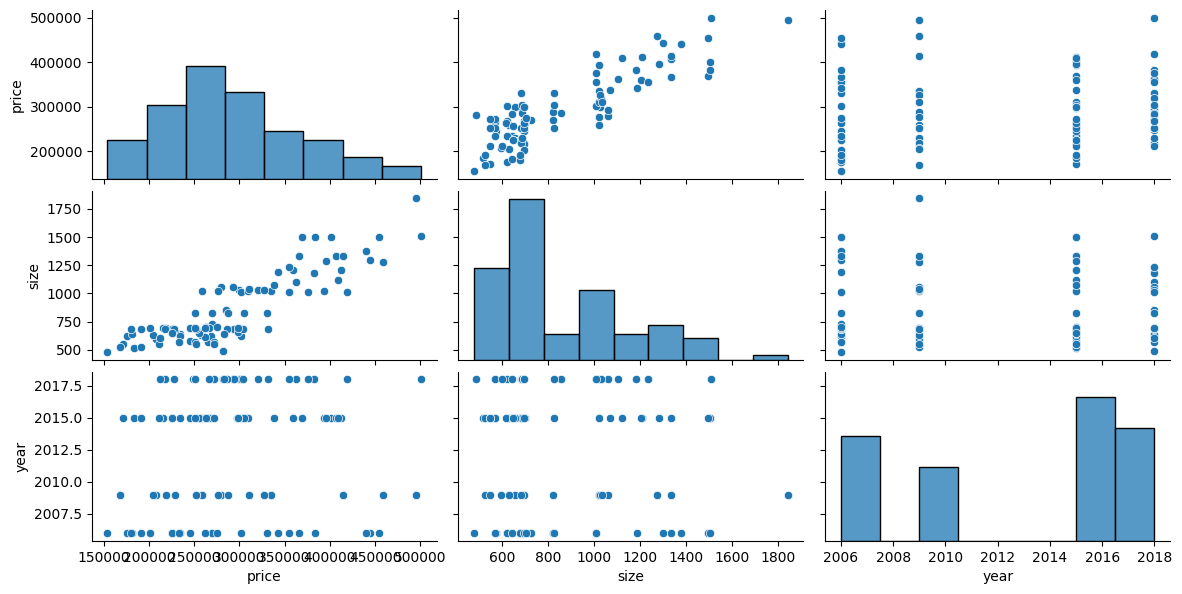

In [ ]:
import seaborn as sns
sns.pairplot(data,height=2,aspect=2)

In [ ]:
data.describe()

,price,size,year
count,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000
std,77051.727525,297.941951,4.729021
min,154282.128000,479.750000,2006.000000
25%,234280.148000,643.330000,2009.000000
50%,280590.716000,696.405000,2015.000000
75%,335723.696000,1029.322500,2018.000000
max,500681.128000,1842.510000,2018.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   100 non-null    float64
 1   size    100 non-null    float64
 2   year    100 non-null    int64  
 3   view    100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.2+ KB


In [ ]:
data1=pd.get_dummies(data)
data1

,price,size,year,view_No sea view,view_Sea view
0,234314.144,643.09,2015,True,False
1,228581.528,656.22,2009,True,False
2,281626.336,487.29,2018,False,True
3,401255.608,1504.75,2015,True,False
4,458674.256,1275.46,2009,False,True
...,...,...,...,...,...
95,252460.400,549.80,2009,False,True
96,310522.592,1037.44,2009,True,False
97,383635.568,1504.75,2006,True,False
98,225145.248,648.29,2015,True,False


Step 3 :: SPLITTING

In [ ]:
x=data1.drop('price',axis='columns')
x

,size,year,view_No sea view,view_Sea view
0,643.09,2015,True,False
1,656.22,2009,True,False
2,487.29,2018,False,True
3,1504.75,2015,True,False
4,1275.46,2009,False,True
...,...,...,...,...
95,549.80,2009,False,True
96,1037.44,2009,True,False
97,1504.75,2006,True,False
98,648.29,2015,True,False


In [ ]:
y=data1.price
print(x)
print(y)

       size  year  view_No sea view  view_Sea view
0    643.09  2015              True          False
1    656.22  2009              True          False
2    487.29  2018             False           True
3   1504.75  2015              True          False
4   1275.46  2009             False           True
..      ...   ...               ...            ...
95   549.80  2009             False           True
96  1037.44  2009              True          False
97  1504.75  2006              True          False
98   648.29  2015              True          False
99   705.29  2006             False           True

[100 rows x 4 columns]
0     234314.144
1     228581.528
2     281626.336
3     401255.608
4     458674.256
         ...    
95    252460.400
96    310522.592
97    383635.568
98    225145.248
99    274922.856
Name: price, Length: 100, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=2)

Step 4 :: PREDICTION AND ERROR CALCULATIONS

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
equation=LinearRegression()
equation.fit(x_train,y_train)

LinearRegression()

In [ ]:
equation.intercept_

-5778726.325474444

In [ ]:
equation.coef_

array([   242.12526906,   2914.12242819, -31226.44185297,  31226.44185297])

In [ ]:
y_test_predicted=equation.predict(x_test)
y_test_predicted

array([288907.51573793, 280403.2467037 , 320634.09793863, 171831.07862285,
       237943.47604893, 187516.82244284, 251184.39881823, 447476.13062718,
       289361.06617231, 315111.22055134, 268998.23833529, 292617.65104118,
       419744.74738039, 413224.99735682, 217712.26474743, 195097.76461714,
       426341.92408649, 424310.49307907, 231128.4259061 , 386024.64463052,
       284035.95532442, 553090.30410134, 299171.20589342, 327486.24305305,
       195124.39839674, 237497.74083046, 400335.98581247, 358796.14506756,
       236718.32218748, 353914.99235229, 262263.31425465, 203406.63496109,
       200681.08061269, 277768.10828967, 235096.76635702, 272164.46067337,
       262683.70402717, 370238.30181114, 321453.25752928, 301259.14119938])

In [ ]:
from sklearn import metrics
MAE=metrics.mean_absolute_error(y_test,y_test_predicted)
print(MAE)
MSE=metrics.mean_squared_error(y_test,y_test_predicted)
print(MSE)
RMSE=np.sqrt(MSE)
print(RMSE)
R2=metrics.r2_score(y_test,y_test_predicted)
print(R2)

23161.938025069692
918151864.5451628
30301.020849884957
0.829108270502144


Step 5 :: PLOTTING

<Axes: xlabel='price'>

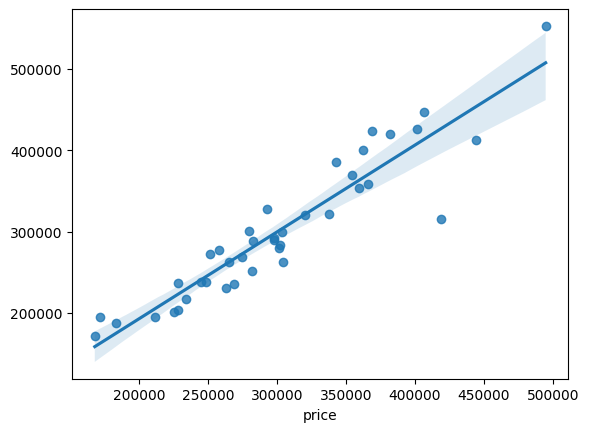

In [ ]:
sns.regplot(x=y_test,y=y_test_predicted)